## ATIVIDADE EXTENSIONISTA IV

### Análise de Dados Climáticos de Araras e Percepção da Sociedade.

DAVID MAIA SOUZA - 4152257

In [ ]:
# Importando as bibliotecas
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Importando os dados
dataset = pd.read_csv("nasapower_Araras.csv")
dados = dataset.copy()
display(dados.head())

,YEAR,MO,DY,T2M_MIN,T2M_MAX,T2M,PRECTOTCORR
0,1981,1,1,15.36,28.92,21.80,0.00
1,1981,1,2,16.84,29.72,23.06,1.31
2,1981,1,3,19.18,28.08,23.20,4.18
3,1981,1,4,19.34,29.17,23.89,4.30
4,1981,1,5,20.22,26.82,23.47,5.27


In [ ]:
# Renomeando as colunas
dados = dados.rename(columns={"YEAR":"ANO", "MO":"MÊS", "DY":"DIA","T2M_MIN": "TEMP. MÍNIMA","T2M_MAX": "TEMP. MÁXIMA",  "T2M": "TEMP. MÉDIA", "PRECTOTCORR":"CHUVA" })
display(dados.head(-5))

,ANO,MÊS,DIA,TEMP. MÍNIMA,TEMP. MÁXIMA,TEMP. MÉDIA,CHUVA
0,1981,1,1,15.36,28.92,21.80,0.00
1,1981,1,2,16.84,29.72,23.06,1.31
2,1981,1,3,19.18,28.08,23.20,4.18
3,1981,1,4,19.34,29.17,23.89,4.30
4,1981,1,5,20.22,26.82,23.47,5.27
...,...,...,...,...,...,...,...
16582,2026,5,27,17.38,27.70,21.95,0.12
16583,2026,5,28,14.13,25.27,19.29,0.00
16584,2026,5,29,11.92,25.83,17.90,0.01
16585,2026,5,30,13.64,25.64,18.65,0.03


In [ ]:
# Criando uma coluna "DATA" para juntar dia, mês e ano
dados["DATA"] = dados["DIA"].astype(str) + '-' + dados["MÊS"].astype(str) + '-' + dados["ANO"].astype(str)

# Selecionando o intervalo de 1981 até 2025 (excluindo dados de 2026)
dados = dados.loc[dados["ANO"] != 2026]
display(dados)


,ANO,MÊS,DIA,TEMP. MÍNIMA,TEMP. MÁXIMA,TEMP. MÉDIA,CHUVA,DATA
0,1981,1,1,15.36,28.92,21.80,0.00,1-1-1981
1,1981,1,2,16.84,29.72,23.06,1.31,2-1-1981
2,1981,1,3,19.18,28.08,23.20,4.18,3-1-1981
3,1981,1,4,19.34,29.17,23.89,4.30,4-1-1981
4,1981,1,5,20.22,26.82,23.47,5.27,5-1-1981
...,...,...,...,...,...,...,...,...
16431,2025,12,27,23.03,37.59,30.20,1.10,27-12-2025
16432,2025,12,28,24.78,36.23,29.96,11.00,28-12-2025
16433,2025,12,29,23.15,36.18,28.92,5.09,29-12-2025
16434,2025,12,30,22.07,35.46,28.29,4.17,30-12-2025


/tmp/ipykernel_2502/2300526002.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="ANO", y="CHUVA", data=chuva_por_ano, alpha=0.8, palette="mako")


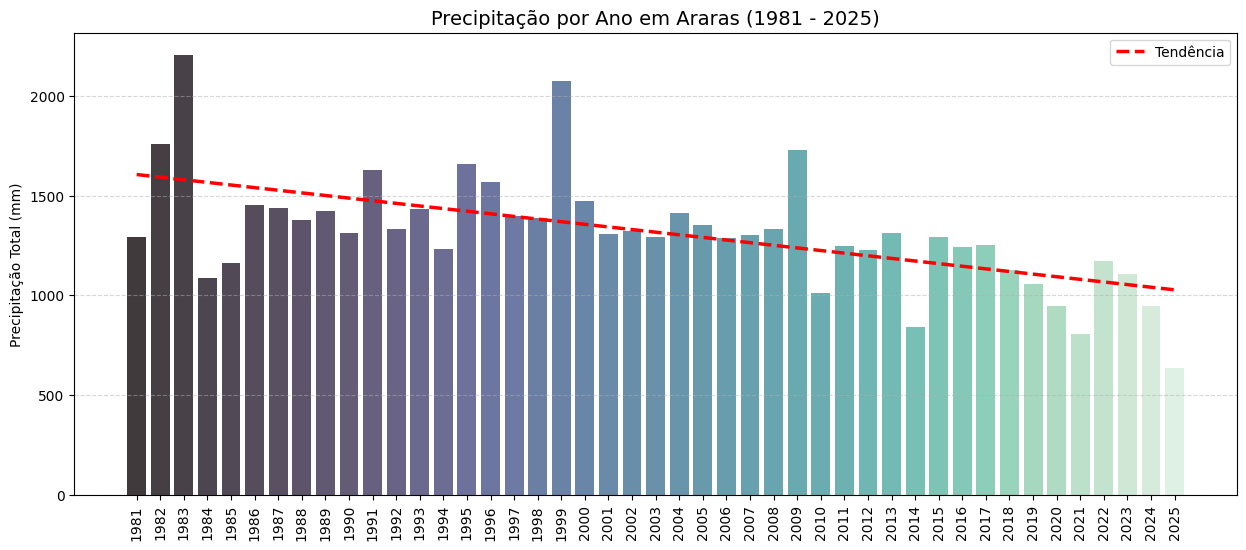

In [ ]:
# Agrupando o total de chuva anual
chuva_por_ano = dados.groupby("ANO")["CHUVA"].sum().reset_index()

plt.figure(figsize=(15, 6))

# Gráfico de barras com a paleta "mako"
ax = sns.barplot(x="ANO", y="CHUVA", data=chuva_por_ano, alpha=0.8, palette="mako")

# Linha de tendência
x_indices = np.arange(len(chuva_por_ano))
y_valores = chuva_por_ano["CHUVA"]
m_chuva, c_chuva = np.polyfit(x_indices, y_valores, 1)

# Plotando a linha de tendência
plt.plot(x_indices, m_chuva * x_indices + c_chuva, color="red", linestyle="--", linewidth=2.5, label="Tendência")

# Plotando gráfico de barras de precipitação anual
plt.title("Precipitação Total por Ano em Araras (1981 - 2025)",fontsize=14)
plt.ylabel("Precipitação Total (mm)")
plt.xlabel("") # forçando não escrever
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

/tmp/ipykernel_2502/2391002719.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(x="ANO",y="TEMP. MÉDIA",data=temp_media_por_ano, marker="o",markersize=6 , palette="light_blue")


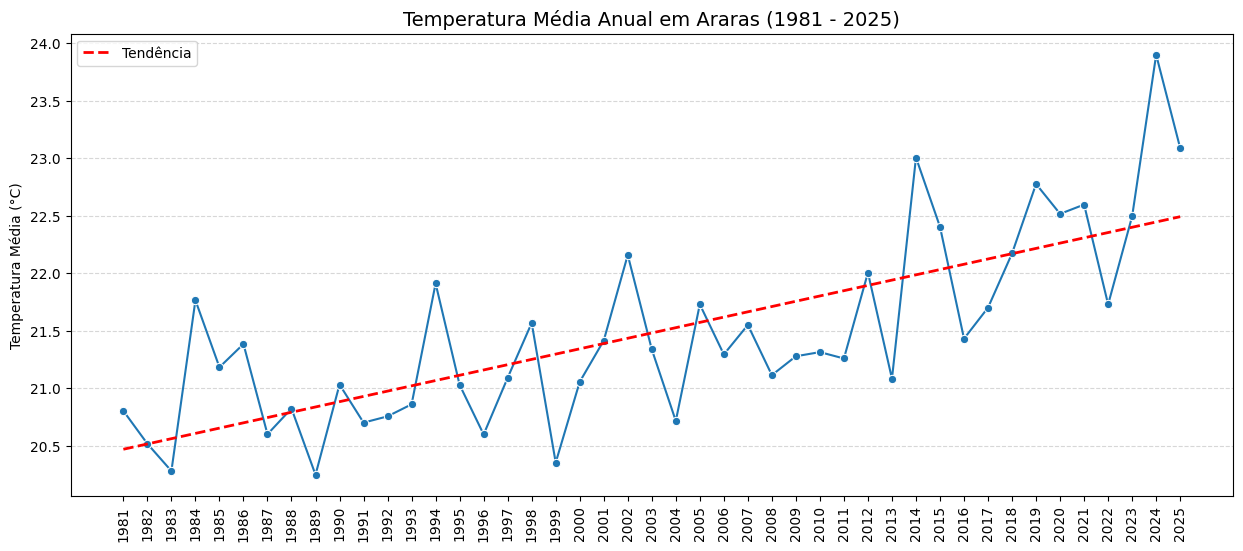

In [ ]:
# Agrupando a temperatura média anual
temp_media_por_ano = dados.groupby("ANO")["TEMP. MÉDIA"].mean().reset_index()

plt.figure(figsize=(15, 6))

# Gráfico de Linhas
ax = sns.lineplot(x="ANO",y="TEMP. MÉDIA",data=temp_media_por_ano, marker="o",markersize=6 , palette="light_blue")

# Linha de Tendência
x_indices = temp_media_por_ano["ANO"]
y_valores = temp_media_por_ano["TEMP. MÉDIA"]
m, c = np.polyfit(x_indices, y_valores, 1) # Ajuste linear

# Plotando a linha de tendência
plt.plot(x_indices, m*x_indices + c, color='red', linestyle='--', linewidth=2, label="Tendência")

# Plotando o Gráfico de Linhas
plt.title("Temperatura Média Anual em Araras (1981 - 2025)", fontsize=14)
plt.ylabel("Temperatura Média (°C)")
plt.xlabel("") # forçando não escrever
plt.xticks(x_indices, rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.show()


/tmp/ipykernel_2502/4257537660.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(x="ANO",y="TEMP. MÁXIMA",data=temp_maxima_por_ano, marker="o",markersize=6 , palette="light_blue")


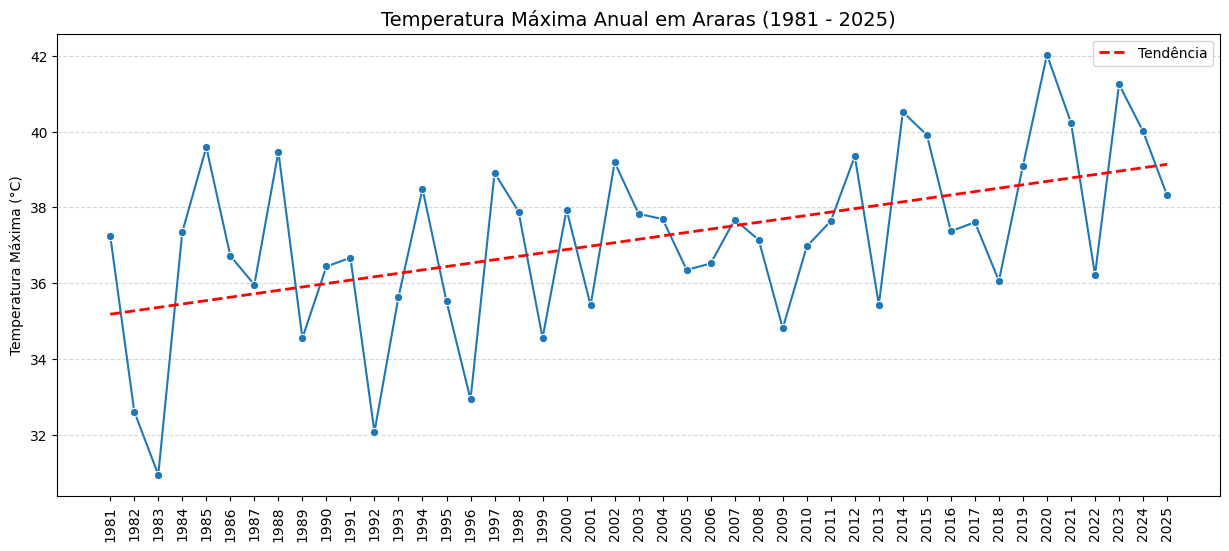

In [ ]:
# Agrupando a temperatura máxima anual
temp_maxima_por_ano = dados.groupby("ANO")["TEMP. MÁXIMA"].max().reset_index()

plt.figure(figsize=(15, 6))

# Gráfico de Linhas
ax = sns.lineplot(x="ANO",y="TEMP. MÁXIMA",data=temp_maxima_por_ano, marker="o",markersize=6 , palette="light_blue")

# Linha de Tendência
x_indices = temp_maxima_por_ano["ANO"]
y_valores = temp_maxima_por_ano["TEMP. MÁXIMA"]
m, c = np.polyfit(x_indices, y_valores, 1) # Ajuste linear

# Plotando a linha de tendência
plt.plot(x_indices, m*x_indices + c, color='red', linestyle='--', linewidth=2, label="Tendência")


# Plotando o Gráfico de Linhas
plt.title("Temperatura Máxima Anual em Araras (1981 - 2025)", fontsize=14)
plt.ylabel("Temperatura Máxima (°C)")
plt.xlabel("") # forçando não escrever
plt.xticks(x_indices, rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=90)
plt.legend()
plt.show()


/tmp/ipykernel_2502/3120841110.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(x="ANO",y="TEMP. MÍNIMA",data=temp_minima_por_ano, marker="o",markersize=6 , palette="light_blue")


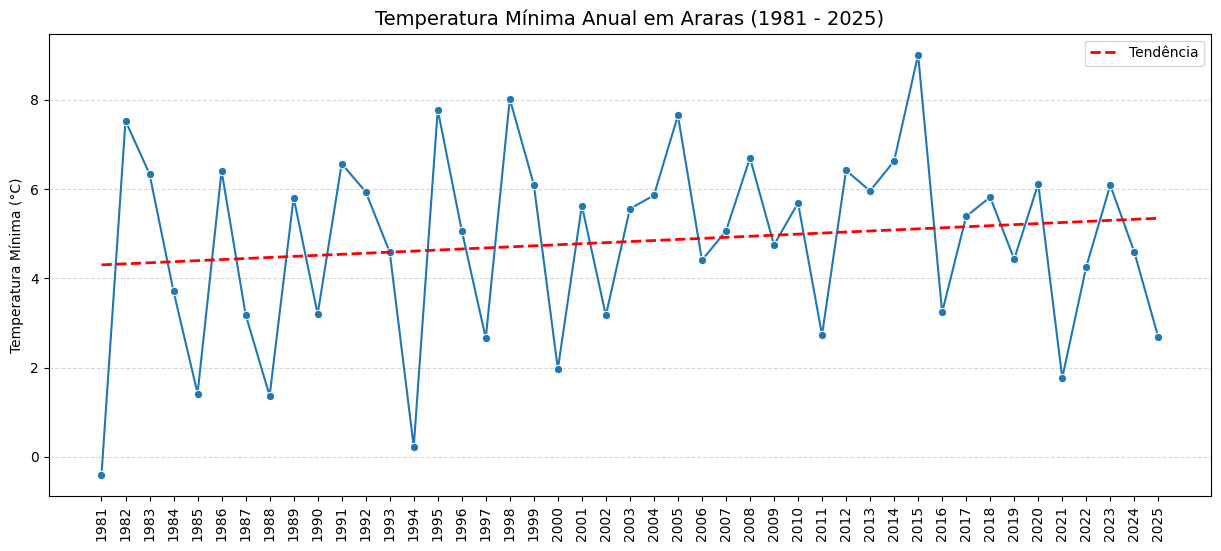

In [ ]:
# Agrupando a temperatura máxima anual
temp_minima_por_ano = dados.groupby("ANO")["TEMP. MÍNIMA"].min().reset_index()

plt.figure(figsize=(15, 6))

# Gráfico de Linhas
ax = sns.lineplot(x="ANO",y="TEMP. MÍNIMA",data=temp_minima_por_ano, marker="o",markersize=6 , palette="light_blue")

# Linha de Tendência
x_indices = temp_minima_por_ano["ANO"]
y_valores = temp_minima_por_ano["TEMP. MÍNIMA"]
m, c = np.polyfit(x_indices, y_valores, 1) # Ajuste linear

# Plotando a linha de tendência
plt.plot(x_indices, m*x_indices + c, color='red', linestyle='--', linewidth=2, label="Tendência")


# Plotando o Gráfico de Linhas
plt.title("Temperatura Mínima Anual em Araras (1981 - 2025)", fontsize=14)
plt.ylabel("Temperatura Mínima (°C)")
plt.xlabel("") # forçando não escrever
plt.xticks(x_indices, rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=90)
plt.legend()
plt.show()
